# Sampling

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io
import skimage.transform as transform
from scipy.fft import fft2, fftshift

import matplotlib as mpl
plt.style.use('../../src/bip.mplstyle')
plt.rcParams['image.cmap'] = 'gray'

# Illustration

In [18]:
def arrow(ax, x1, x2, y, offset, s, fontsize=25):
    """Flèche avec annotation au centre"""
    ax.annotate('', xy=(x1,y), xytext=(x2,y),
        color='lime', arrowprops=dict(
            arrowstyle='<->',
            color='lime',
        ))
    xc = (x1+x2) / 2
    ax.text(xc, y+offset, s, fontsize=fontsize, color='lime', ha='center')

In [19]:
# Chargement de l'image (nécessairement carrée)
img = io.imread("../../src/figs/michel.jpg")

# Redimensionne l'image pour être de taille impaire sans être trop grande
S = 201
img = transform.resize(img, (S,S))

# Demi-taille de l'image
H = (S-1) // 2

# Transformée de Fourier de l'image observée
img_fft = fftshift(fft2(img))

# Module de la transformée de Fourier, avec un min à 0
mod = np.log(np.abs(img_fft))
mod = mod - mod.min()

# Fenêtrage par une gaussienne
[m, n] = np.meshgrid(range(S), range(S))
gauss = np.exp( - ((m-S/2)**2 + (n-S/2)**2) / 1e4 )
mod = mod * gauss

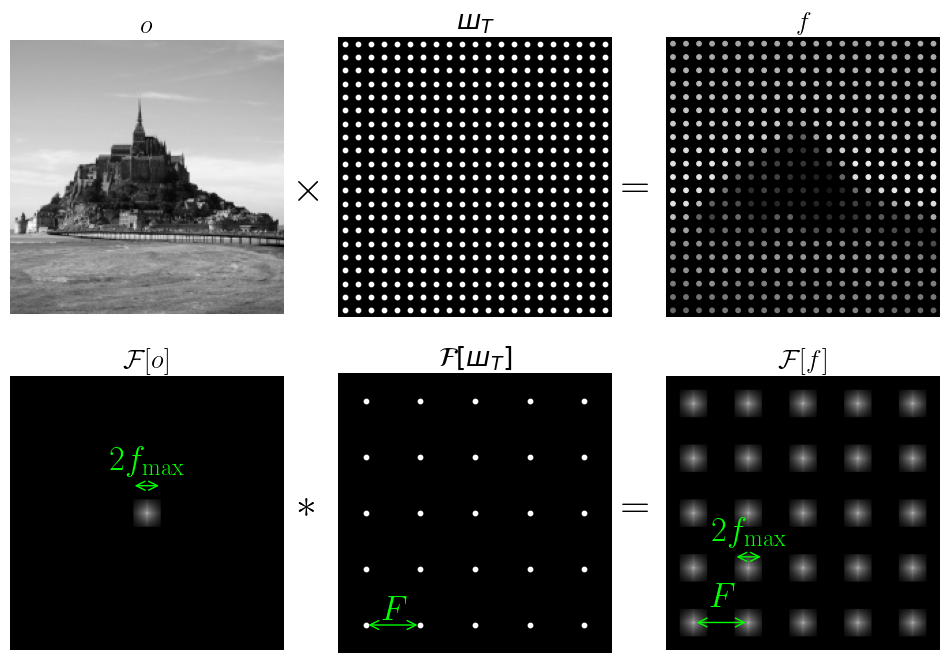

In [53]:
# Préparation de l'affichage
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = False
plt.rcParams['axes.spines.right'] = False
fig, axs = plt.subplots(2, 3, figsize=(12,8))

# ============================================================================ #

# Domaine spatial

# Nombre de Diracs en spatial (entier impair)
L = 21

# Limite pour les axes des scatterplot
lim = [-.5, L-.5]

# Image observée
axs[0][0].imshow(img)

# Champ de Diracs en spatial
ii, jj = np.meshgrid(range(L), range(L))
ii, jj = ii.ravel(), jj.ravel()
axs[0,1].scatter(ii, jj, color='w', s=10)
axs[0,1].set_facecolor('k')
axs[0,1].set_xlim(lim)
axs[0,1].set_ylim(lim)

# Image échantillonnée
intensities = transform.resize(img, (L,L), order=0).ravel()  # Interpolation pour avoir une image de taille L × L
intensities = np.tile(intensities, (3,1)).T                  # Array de niveaux de gris de taille (L**2, 3)
axs[0,2].scatter(ii, jj, color=intensities, s=10)
axs[0,2].set_facecolor('k')
axs[0,2].set_xlim(lim)
axs[0,2].set_ylim(lim[::-1])

# ============================================================================ #

# Domaine de Fourier

# Nombre de Diracs en spectral (entier impair)
K = 5

# Fréquence d'échantillonnage (en pixel)
# si F = S : on est tout pile à la limite de Shannon
# si F < S : il y a du repliement spectral
# si F > S : il n'y a pas de repliement spectral
F = int(2 * S)

# Transformée de Fourier (avec la même taille que la périodisation)
per = np.zeros((K*F, K*F))
i = (K-1) // 2
a = int( (i+.5) * F - H )
b = a + S
per[a:b, a:b] = mod
axs[1,0].imshow(per)

# Champ de Diracs en spectral
ii, jj = np.meshgrid(range(K), range(K))
ii, jj = ii.ravel(), jj.ravel()
axs[1,1].scatter(ii, jj, color='w', s=10)
axs[1,1].set_facecolor('k')
axs[1,1].set_xlim([-.5, K-.5])
axs[1,1].set_ylim([-.5, K-.5])

# Périodisation du spectre
per = np.zeros((K*F, K*F))
for i in range(K):
    for j in range(K):
        a = int( (i+.5) * F - H )
        b = a + S
        c = int( (j+.5) * F - H )
        d = c + S
        per[a:b, c:d] = mod
axs[1,2].imshow(per)

# ============================================================================ #

# Texte
fs = 30

# Opérateurs mathématiques
fig.text(0.365, 0.68, r"$\times$", fontsize=fs)
fig.text(0.365, 0.28, "$*$", fontsize=fs)
fig.text(0.635, 0.68, "=", fontsize=fs)
fig.text(0.635, 0.28, "=", fontsize=fs)

# Flèches
arrow(axs[1,0], 2.5*F-1.1*H,    K/2*F+1.1*H,    2*F,        offset=-F*.3,   s=r"$2f_\mathrm{max}$"  )
arrow(axs[1,1], 0,              1,              0,          offset=.1,      s=r"$F$"                )
arrow(axs[1,2], .5*F,           1.5*F,          (K-.5)*F,   offset=-F*.3,   s=r"$F$"                )
arrow(axs[1,2], 1.5*F-1.1*H,    1.5*F+1.1*H,    (K-1.7)*F,  offset=-F*.3,   s=r"$2f_\mathrm{max}$"  )

# ============================================================================ #

# Finalisation de l'affichage
for axrow in axs:
    for ax in axrow:
        ax.set_xticks([])
        ax.set_yticks([])

axs[0,0].set_title("$o$")
axs[0,1].set_title("$ш_T$", usetex=False)
axs[0,2].set_title("$f$")

axs[1,0].set_title(r"$\mathcal{F}[o]$")
axs[1,1].set_title(r"$\mathcal{F}[ш_T]$", usetex=False)
axs[1,2].set_title(r"$\mathcal{F}[f]$")

plt.savefig("sampling.svg")